# MedicalPatchNet Kaggle Inference

Inference pretrained `patrick-w/MedicalPatchNet` on one chest X-ray image. Fill `IMAGE_PATH`, enable Internet in Kaggle, then run top-to-bottom. This notebook does not train the model.

Official sources:
- Code: https://github.com/TruhnLab/MedicalPatchNet
- Weights: https://huggingface.co/patrick-w/MedicalPatchNet

In [1]:
!pip install -q huggingface_hub matplotlib pillow opencv-python-headless

import os
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from huggingface_hub import hf_hub_download
from PIL import Image

In [6]:
# ===== User config =====
IMAGE_PATH = "/kaggle/input/datasets/snikhilrao/chexlocalize-dataset/chexlocalize_dataset/chexlocalize/CheXpert/test/patient64743/study1/view1_frontal.jpg"  # TODO: replace with your image path

IMG_SIZE = 512
PATCH_SIZE = 64
HF_REPO_ID = "patrick-w/MedicalPatchNet"
CHECKPOINT_FILENAME = "MedicalPatchNet_weights.pt"
OUTPUT_DIR = Path("/kaggle/working/medicalpatchnet_outputs")

# Paper-like shifted localization. 64 = blocky 8x8 patches, 16 = smoother, 4 = very smooth but slower, 1 = extremely slow.
SHIFT_PIXELS = 16
SHIFT_BATCH_SIZE = 8
USE_SCALED_PATCH_MAPS = True

# Signed-logit visualization: red supports the class, blue argues against it, white/grey is near zero.
VIS_LOGIT_CLIP = 20.0
MASK_LOGIT_THRESHOLD = 5.0
TOP_K_TO_DISPLAY = 5
RUN_SHIFT_COMPARISON = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert IMG_SIZE % PATCH_SIZE == 0
assert PATCH_SIZE % SHIFT_PIXELS == 0

In [3]:
# Import the official model class from the official repository.
REPO_DIR = Path("/kaggle/working/MedicalPatchNet")
if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/TruhnLab/MedicalPatchNet.git /kaggle/working/MedicalPatchNet

sys.path.insert(0, str(REPO_DIR))
from NetworkModel import ScalePatchNet

PATHOLOGY_NAMES = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
]

Cloning into '/kaggle/working/MedicalPatchNet'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 46 (delta 1), reused 42 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 8.33 MiB | 25.24 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

checkpoint_path = hf_hub_download(repo_id=HF_REPO_ID, filename=CHECKPOINT_FILENAME)
print("Checkpoint:", checkpoint_path)

model = ScalePatchNet(patchSize=PATCH_SIZE, outFeatures=len(PATHOLOGY_NAMES))
state_dict = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]
state_dict = {k.replace("_orig_mod.", "").replace("module.", ""): v for k, v in state_dict.items()}
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
assert not missing and not unexpected, "Checkpoint keys do not match ScalePatchNet."

model = model.to(device).eval()

Device: cpu


MedicalPatchNet_weights.pt:   0%|          | 0.00/81.7M [00:00<?, ?B/s]

Checkpoint: /root/.cache/huggingface/hub/models--patrick-w--MedicalPatchNet/snapshots/5dbb5e617c138146b0b1f167d44da17b79c2631b/MedicalPatchNet_weights.pt
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 149MB/s] 


Missing keys: []
Unexpected keys: []


Original size: (2494, 2048)
Center-crop box: (223, 0, 2271, 2048)
Model input: (1, 1, 512, 512)


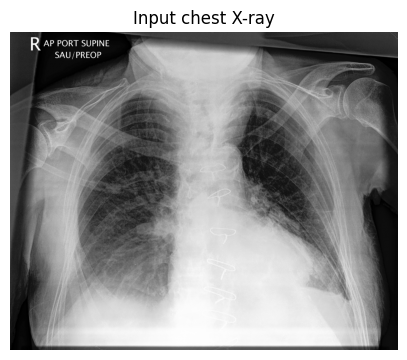

In [7]:
def center_square_crop_pil(img: Image.Image):
    width, height = img.size
    crop_len = min(width, height)
    left = (width - crop_len) // 2
    top = (height - crop_len) // 2
    return img.crop((left, top, left + crop_len, top + crop_len)), (left, top, left + crop_len, top + crop_len)


def load_and_preprocess(image_path: str, img_size: int = IMG_SIZE):
    img_orig = Image.open(image_path).convert("L")
    img_crop, crop_box = center_square_crop_pil(img_orig)
    img_tensor = TF.to_tensor(img_crop)
    img_tensor = TF.resize(img_tensor, [img_size, img_size], antialias=True)
    return img_orig, img_crop, crop_box, img_tensor.unsqueeze(0)


def safe_name(name: str) -> str:
    return name.lower().replace(" ", "_").replace("/", "_")


def shift_tensor_2d(x: torch.Tensor, dx: int, dy: int, fill: float = 0.0):
    """Shift [B,C,H,W] by dx/dy pixels with constant fill instead of circular wrap."""
    b, c, h, w = x.shape
    out = x.new_full((b, c, h, w), fill)
    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx) if dx >= 0 else w
    dst_x0 = max(0, dx)
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy) if dy >= 0 else h
    dst_y0 = max(0, dy)
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    if src_x1 > src_x0 and src_y1 > src_y0:
        out[:, :, dst_y0:dst_y1, dst_x0:dst_x1] = x[:, :, src_y0:src_y1, src_x0:src_x1]
    return out


def patch_features_to_grid_maps(patch_features: torch.Tensor, img_size: int = IMG_SIZE, patch_size: int = PATCH_SIZE):
    grid = img_size // patch_size
    maps = patch_features.reshape(patch_features.shape[0], grid, grid, -1).permute(0, 3, 1, 2)
    return F.interpolate(maps, size=(img_size, img_size), mode="nearest")


def shifted_patch_logit_maps(model, img, shift_pixels=16, batch_size=8, use_scaled=True):
    """Average patch-logit maps over shifted patch grids, matching the visual idea in the paper figure."""
    shifts = [(dx, dy) for dy in range(0, PATCH_SIZE, shift_pixels) for dx in range(0, PATCH_SIZE, shift_pixels)]
    total = None
    counts = None
    fill_value = float(img.min().detach().cpu())

    for start in range(0, len(shifts), batch_size):
        batch_shifts = shifts[start:start + batch_size]
        shifted_imgs = torch.cat([shift_tensor_2d(img, dx, dy, fill=fill_value) for dx, dy in batch_shifts], dim=0)
        patch_features = model.forwardScaledPatches(shifted_imgs) if use_scaled else model.forwardRawPatches(shifted_imgs)
        batch_maps = patch_features_to_grid_maps(patch_features)

        for i, (dx, dy) in enumerate(batch_shifts):
            unshifted = shift_tensor_2d(batch_maps[i:i + 1], -dx, -dy, fill=0.0)[0]
            valid = shift_tensor_2d(torch.ones_like(img[:, :1]), dx, dy, fill=0.0)
            valid = shift_tensor_2d(valid, -dx, -dy, fill=0.0)[0, 0]
            if total is None:
                total = torch.zeros_like(unshifted)
                counts = torch.zeros_like(valid)
            total += unshifted * valid.unsqueeze(0)
            counts += valid

    return total / counts.clamp_min(1).unsqueeze(0)


def paste_crop_map_to_original(map_crop: np.ndarray, original_size, crop_box, interpolation=cv2.INTER_LINEAR):
    orig_w, orig_h = original_size
    left, top, right, bottom = crop_box
    crop_w, crop_h = right - left, bottom - top
    resized = cv2.resize(map_crop.astype(np.float32), (crop_w, crop_h), interpolation=interpolation)
    canvas = np.zeros((orig_h, orig_w), dtype=np.float32)
    canvas[top:bottom, left:right] = resized
    return canvas


def signed_overlay(gray_img_pil: Image.Image, signed_map: np.ndarray, clip_value=20.0, alpha=0.58, valid_mask=None):
    gray = np.array(gray_img_pil.convert("L"))
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
    signed = np.clip(signed_map / clip_value, -1.0, 1.0)
    rgba = plt.get_cmap("RdBu_r")((signed + 1.0) / 2.0)
    color = rgba[..., :3].astype(np.float32)
    strength = np.clip(np.abs(signed), 0.0, 1.0)
    local_alpha = alpha * np.sqrt(strength)[..., None]
    if valid_mask is not None:
        local_alpha *= valid_mask.astype(np.float32)[..., None]
    blended = base * (1.0 - local_alpha) + color * local_alpha
    return np.clip(blended, 0, 1)


img_orig, img_crop, crop_box, input_tensor = load_and_preprocess(IMAGE_PATH)
valid_overlay_mask = paste_crop_map_to_original(np.ones((IMG_SIZE, IMG_SIZE), dtype=np.float32), img_orig.size, crop_box) > 0
input_tensor = input_tensor.to(device)
print("Original size:", img_orig.size)
print("Center-crop box:", crop_box)
print("Model input:", tuple(input_tensor.shape))

plt.figure(figsize=(5, 5))
plt.imshow(img_orig, cmap="gray")
plt.axis("off")
plt.title("Input chest X-ray")
plt.show()

In [8]:
if device.type == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

t0 = time.perf_counter()
with torch.inference_mode():
    global_logits = model(input_tensor)[0]
    probabilities = torch.sigmoid(global_logits).detach().cpu().numpy()
    signed_maps_512 = shifted_patch_logit_maps(
        model,
        input_tensor,
        shift_pixels=SHIFT_PIXELS,
        batch_size=SHIFT_BATCH_SIZE,
        use_scaled=USE_SCALED_PATCH_MAPS,
    ).detach().cpu().numpy()

if device.type == "cuda":
    torch.cuda.synchronize()
elapsed_s = time.perf_counter() - t0

ranked = sorted(zip(PATHOLOGY_NAMES, probabilities), key=lambda x: x[1], reverse=True)
print("Pathology probabilities:")
for name, prob in ranked:
    print(f"{name:28s} {prob:.6f}")

Pathology probabilities:
Lung Opacity                 0.975241
Enlarged Cardiomediastinum   0.957356
Atelectasis                  0.940917
Cardiomegaly                 0.904909
Pleural Effusion             0.888878
Consolidation                0.787333
Edema                        0.742105
Fracture                     0.595735
Support Devices              0.259645
Pneumonia                    0.237045
Pleural Other                0.176016
Lung Lesion                  0.036566
Pneumothorax                 0.016912
No Finding                   0.010658


In [9]:
# Save pathology-specific signed heatmaps, paper-style overlays, and estimated positive-evidence masks.
saved = []
signed_maps_original = {}

for idx, pathology in enumerate(PATHOLOGY_NAMES):
    signed_original = paste_crop_map_to_original(signed_maps_512[idx], img_orig.size, crop_box)
    signed_maps_original[pathology] = signed_original

    overlay = signed_overlay(img_orig, signed_original, clip_value=VIS_LOGIT_CLIP, valid_mask=valid_overlay_mask)
    mask = ((signed_original >= MASK_LOGIT_THRESHOLD) & valid_overlay_mask).astype(np.uint8) * 255
    signed_vis = ((np.clip(signed_original / VIS_LOGIT_CLIP, -1, 1) + 1) * 127.5).astype(np.uint8)

    stem = safe_name(pathology)
    heat_path = OUTPUT_DIR / f"{stem}_signed_heatmap.png"
    overlay_path = OUTPUT_DIR / f"{stem}_paper_style_overlay.png"
    mask_path = OUTPUT_DIR / f"{stem}_positive_mask_logit_thr_{MASK_LOGIT_THRESHOLD:.1f}.png"

    cv2.imwrite(str(heat_path), signed_vis)
    cv2.imwrite(str(overlay_path), cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(mask_path), mask)
    saved.append((pathology, heat_path, overlay_path, mask_path))

print(f"Saved outputs to: {OUTPUT_DIR}")
for pathology, _, overlay_path, mask_path in saved:
    print(f"{pathology:28s} overlay -> {overlay_path.name} | mask -> {mask_path.name}")

Saved outputs to: /kaggle/working/medicalpatchnet_outputs
No Finding                   overlay -> no_finding_paper_style_overlay.png | mask -> no_finding_positive_mask_logit_thr_5.0.png
Enlarged Cardiomediastinum   overlay -> enlarged_cardiomediastinum_paper_style_overlay.png | mask -> enlarged_cardiomediastinum_positive_mask_logit_thr_5.0.png
Cardiomegaly                 overlay -> cardiomegaly_paper_style_overlay.png | mask -> cardiomegaly_positive_mask_logit_thr_5.0.png
Lung Opacity                 overlay -> lung_opacity_paper_style_overlay.png | mask -> lung_opacity_positive_mask_logit_thr_5.0.png
Lung Lesion                  overlay -> lung_lesion_paper_style_overlay.png | mask -> lung_lesion_positive_mask_logit_thr_5.0.png
Edema                        overlay -> edema_paper_style_overlay.png | mask -> edema_positive_mask_logit_thr_5.0.png
Consolidation                overlay -> consolidation_paper_style_overlay.png | mask -> consolidation_positive_mask_logit_thr_5.0.png
Pneumoni

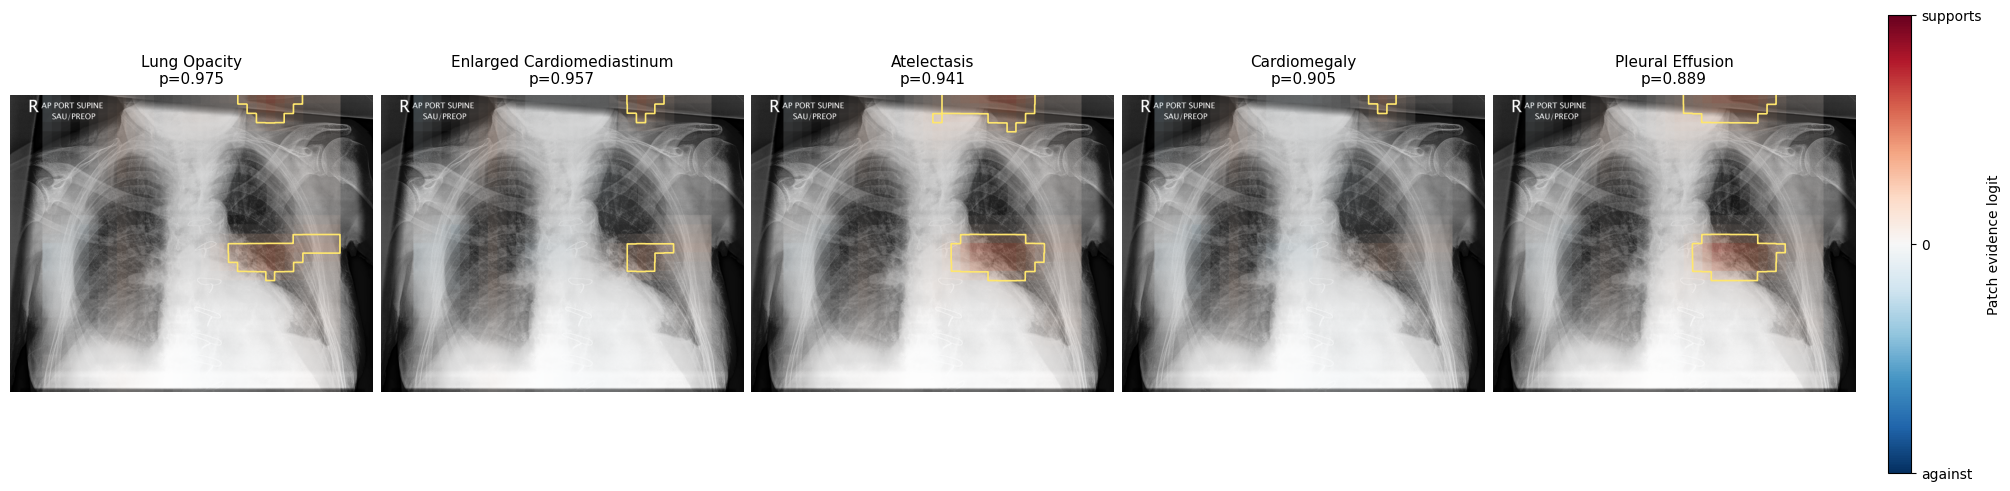

In [10]:
# Paper-style display: red = positive evidence, blue = negative evidence, grey/white = near-zero abstention.
top_indices = np.argsort(probabilities)[::-1][:TOP_K_TO_DISPLAY]
fig, axes = plt.subplots(1, len(top_indices), figsize=(4.0 * len(top_indices), 4.8), constrained_layout=True)
if len(top_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, top_indices):
    pathology = PATHOLOGY_NAMES[idx]
    signed_original = signed_maps_original[pathology]
    overlay = signed_overlay(img_orig, signed_original, clip_value=VIS_LOGIT_CLIP, valid_mask=valid_overlay_mask)
    mask = (signed_original >= MASK_LOGIT_THRESHOLD) & valid_overlay_mask

    ax.imshow(overlay)
    ax.contour(mask.astype(np.uint8), levels=[0.5], colors=["#ffe66d"], linewidths=1.2)
    ax.axis("off")
    ax.set_title(f"{pathology}\np={probabilities[idx]:.3f}", fontsize=11, pad=8)

norm = mcolors.TwoSlopeNorm(vmin=-VIS_LOGIT_CLIP, vcenter=0, vmax=VIS_LOGIT_CLIP)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.028, pad=0.018)
cbar.set_label("Patch evidence logit")
cbar.set_ticks([-VIS_LOGIT_CLIP, 0, VIS_LOGIT_CLIP])
cbar.set_ticklabels(["against", "0", "supports"])
plt.show()

In [11]:
# Optional: compare the paper's shifted-grid smoothness settings for one selected pathology.
# Turn RUN_SHIFT_COMPARISON=True in the config cell to run this. Smaller shift values are prettier but slower.
if RUN_SHIFT_COMPARISON:
    COMPARE_SHIFT_PIXELS = [64, 16, 4]
    COMPARE_PATHOLOGY = PATHOLOGY_NAMES[int(np.argmax(probabilities))]
    COMPARE_CLASS_IDX = PATHOLOGY_NAMES.index(COMPARE_PATHOLOGY)

    compare_maps = []
    with torch.inference_mode():
        for sp in COMPARE_SHIFT_PIXELS:
            if PATCH_SIZE % sp != 0:
                continue
            t_start = time.perf_counter()
            maps_512 = shifted_patch_logit_maps(model, input_tensor, shift_pixels=sp, batch_size=SHIFT_BATCH_SIZE, use_scaled=USE_SCALED_PATCH_MAPS)
            dt = time.perf_counter() - t_start
            signed_original = paste_crop_map_to_original(maps_512[COMPARE_CLASS_IDX].detach().cpu().numpy(), img_orig.size, crop_box)
            compare_maps.append((sp, signed_original, dt))

    fig, axes = plt.subplots(1, len(compare_maps), figsize=(4.2 * len(compare_maps), 4.6), constrained_layout=True)
    if len(compare_maps) == 1:
        axes = [axes]
    for ax, (sp, signed_original, dt) in zip(axes, compare_maps):
        overlay = signed_overlay(img_orig, signed_original, clip_value=VIS_LOGIT_CLIP, valid_mask=valid_overlay_mask)
        ax.imshow(overlay)
        ax.axis("off")
        ax.set_title(f"Shift {sp}px\n{COMPARE_PATHOLOGY}\n{dt:.1f}s", fontsize=10)
    plt.show()
else:
    print("Shift comparison skipped. Set RUN_SHIFT_COMPARISON=True to generate paper-style shift panels.")

Shift comparison skipped. Set RUN_SHIFT_COMPARISON=True to generate paper-style shift panels.


In [12]:
print(f"Inference + shifted localization time: {elapsed_s:.4f} seconds")
print(f"Shift pixels: {SHIFT_PIXELS}; forward-pass grid count: {(PATCH_SIZE // SHIFT_PIXELS) ** 2}")
if device.type == "cuda":
    allocated = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved = torch.cuda.memory_reserved() / (1024 ** 2)
    peak_allocated = torch.cuda.max_memory_allocated() / (1024 ** 2)
    peak_reserved = torch.cuda.max_memory_reserved() / (1024 ** 2)
    print(f"GPU VRAM allocated: {allocated:.2f} MiB")
    print(f"GPU VRAM reserved:   {reserved:.2f} MiB")
    print(f"Peak allocated:      {peak_allocated:.2f} MiB")
    print(f"Peak reserved:       {peak_reserved:.2f} MiB")
else:
    print("CUDA not available; VRAM metrics are not applicable.")

Inference + shifted localization time: 17.4507 seconds
Shift pixels: 16; forward-pass grid count: 16
CUDA not available; VRAM metrics are not applicable.
